<a href="https://colab.research.google.com/github/BialaStrzala/Sztuczna-Inteligencja-Paula-Grzebyk-21236/blob/main/SI_uproszczona_regresja_liniowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paula Grzebyk 21236
**Uproszczona regresja liniowa, minimalizacja**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
observations = 1000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs = np.column_stack((xs, zs))
print(inputs.shape)

(1000, 2)


In [ ]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13*xs + 7*zs - 12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


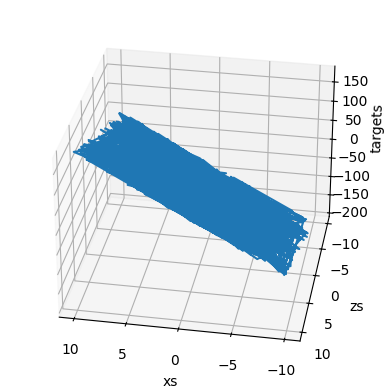

In [ ]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('targets')
ax.view_init(azim=100)
plt.show()

In [ ]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[-0.05977366]
 [-0.07296401]] [0.01825372]


In [ ]:
targets = targets.reshape(observations, 1)
eta = 0.02 #wpolczynnik uczenia sie sieci
for i in range(100):
  outputs = np.dot(inputs, weights) + biases #wyjscia y
  deltas = outputs - targets #roznica miedzy wejsciami a targetem
  loss = np.sum(deltas ** 2) #f straty L2-norm
  #print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

In [ ]:
print(weights,biases)

[[12.99215919]
 [ 7.00375174]] [-10.37673483]


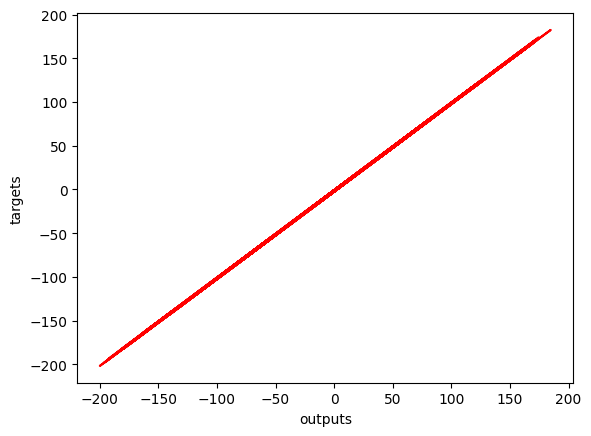

In [ ]:
plt.plot(outputs, targets, color='red')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()

# Wyniki


---


# target = 2* xs + 3* zs + 5
**Test 1** - Wyniki bliskie prawdzie

observations = 1000

eta = 0.02

[[ 2.00929526] [-2.99395748]] [4.32022965]

**Test 2** - Wyniki dalekie od oczekiwanych

observations = 10000

eta = 0.0001

[[ 0.61478021] [-0.87091408]] [-0.00425665]

**Test 2** - Bias daleki od oczekiwanego

observations = 10000

eta = 0.1

[[2.38846441e+36] [3.01302904e+37]] [1.18444857e+35]

**Test 3** - Wyniki dalekie od oczekiwanych

observations = 1000

eta = 0.1

[[9.81424666e+76] [1.29222604e+77]] [-5.06758019e+74]


---


# target = 13* xs + 7* zs – 12
**Test 1** - Wagi bliskie oczekiwanym, bias daleki od oczekiwanego

observations = 1000

eta = 0.01

[[12.99200792] [ 6.99123837]] [-7.58143134]

**Test 2** - Bias bliższy prawdzie, niż w teście 1

observations = 1000

eta = 0.02

[[12.98100058] [ 6.99602346]] [-10.37838392]

**Test 3** - Brak znaczącej poprawy od testu 2

observations = 10000

eta = 0.02

[[12.99641071] [ 6.99849331]] [-10.39730357]

**Test 4** - Wyniki bliskie oczekiwanym

observations = 10000

eta = 0.05

[[12.99962641] [ 6.99994839]] [-11.92948015]

**Test 5** - Bias daleki od oczekiwanego

observations = 1000000

eta = 0.001

[[12.56029078] [ 6.76561   ]] [-1.12968663]

**Test 6** - Wyniki bliskie oczekiwanym

observations = 1000000

eta = 0.02

[[12.99965086] [ 6.9999697 ]] [-10.41460916]

**Test 7** - Wyniki dalekie od oczekiwanych

observations = 1000

eta = 0.5

[[-2.23458266e+124] [ 1.78531012e+124]] [2.24064416e+121]


---

# Wnioski
Za wysoki lub też za niski współczynnik uczenia się sieci (eta) przynosi wyniki dalekie od oczekiwanych.